In [1]:
# instala a biblioteca de augmentation
!pip install albumentations -q

In [19]:
# importa tudo q vou usar
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import albumentations as iaa
import cv2

In [3]:
# define o dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# baixa o FashionMNIST de treino e validação
data_folder = './content'
fmnist      = datasets.FashionMNIST(data_folder, download=True, train=True)
val_fmnist  = datasets.FashionMNIST(data_folder, download=True, train=False)

# separa imagens e rótulos
tr_images,  tr_targets  = fmnist.data, fmnist.targets
val_images, val_targets = val_fmnist.data, val_fmnist.targets

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 287kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.2MB/s]


In [6]:
# define o pipeline de augmentation e desloca a imagen
aug = iaa.Compose([
    iaa.Affine(translate_px={'x': (-10, 10), 'y': (0, 0)}, mode=0, p=1.0)
])

/tmp/ipykernel_5855/3565667320.py:3: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  iaa.Affine(translate_px={'x': (-10, 10), 'y': (0, 0)}, mode=0, p=1.0)


In [13]:
# dataset customizado
class FMNISTDataset(Dataset):
    def __init__(self, x, y, aug=None):
        self.x, self.y = x, y # armazena imagens e rótulos
        self.aug = aug # configuração de augmentation

    def __getitem__(self, ix):
        return self.x[ix], self.y[ix] # retorna uma amostra pelo indice

    def __len__(self):
        return len(self.x)

    def collate_fn(self, batch):
        ims, classes = list(zip(*batch)) # separa imagens e rótulos

        if self.aug:
            augmented_ims = []
            for img_tensor in ims:
                img_np = img_tensor.numpy() # converte torch.Tensor para numpy array
                augmented_img_np = self.aug(image=img_np)['image'] # aplica augmentation
                augmented_ims.append(torch.tensor(augmented_img_np)) # converte de volta para torch.Tensor
            ims = augmented_ims # é agora uma lista de tensores aumentados

        # Empilha as imagens em um único tensor, adiciona a dimensão do canal, converte para float, move para o dispositivo e normaliza
        ims = torch.stack(ims).unsqueeze(1).float().to(device) / 255. # .unsqueeze(1) adiciona a dimensão do canal

        # Converte rótulos para um tensor e move para o dispositivo
        classes = torch.tensor(classes).to(device)
        return ims, classes

In [14]:
# CNN com duas camadas
def get_model():
    model = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3), # primeira conv
        nn.MaxPool2d(2), # reduz resolução
        nn.Conv2d(64, 128, kernel_size=3), # segunda conv
        nn.MaxPool2d(2), # reduz resolução
        nn.ReLU(),# ativação
        nn.Flatten(), # achata para vetor 1D
        nn.Linear(3200, 256), # camada densa
        nn.ReLU(), # ativação
        nn.Linear(256, 10) # saída com 10 classes
    ).to(device)

    loss_fn   = nn.CrossEntropyLoss() # perda para classificação
    optimizer = Adam(model.parameters(), lr=1e-3) # otimizador adam
    return model, loss_fn, optimizer

In [15]:
# treina um batch e retorna
def train_batch(x, y, model, opt, loss_fn):
    model.train() # modo de treino
    prediction = model(x) # forward pass
    batch_loss = loss_fn(prediction, y) # calcula o erro
    batch_loss.backward() # backward pass
    opt.step() # atualiza os pesos
    opt.zero_grad() # limpa os gradientes
    return batch_loss.item()

In [16]:
# cria os dataloaders
def get_data():
    train  = FMNISTDataset(tr_images,  tr_targets,  aug=aug) # treino com augmentation
    val    = FMNISTDataset(val_images, val_targets) # validação sem augmentation
    trn_dl = DataLoader(train, batch_size=64, collate_fn=train.collate_fn, shuffle=True)
    val_dl = DataLoader(val,   batch_size=len(val_images), collate_fn=val.collate_fn, shuffle=False)
    return trn_dl, val_dl

In [17]:
# instancia dados e modelo
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

# loop de treinamento
for epoch in range(5):
    print(f'Época {epoch+1}/5')
    for x, y in trn_dl:
        train_batch(x, y, model, optimizer, loss_fn)

Época 1/5
Época 2/5
Época 3/5
Época 4/5
Época 5/5


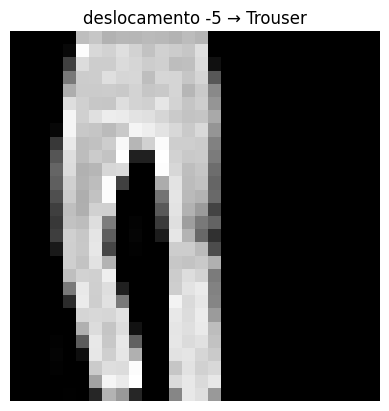

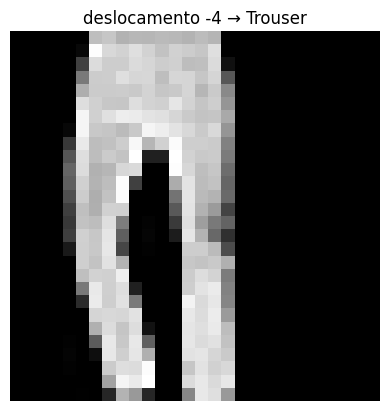

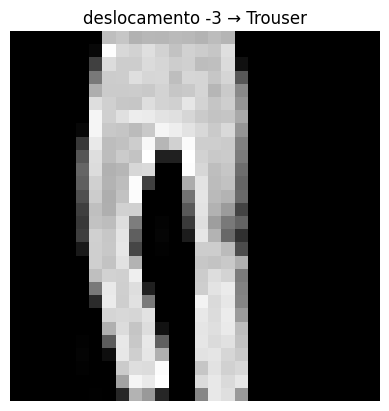

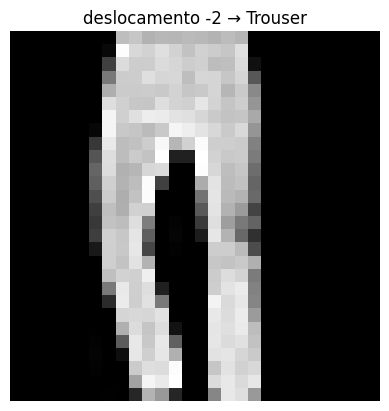

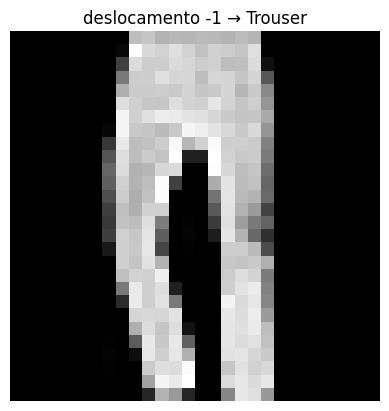

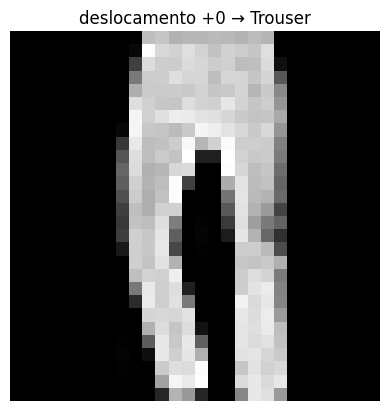

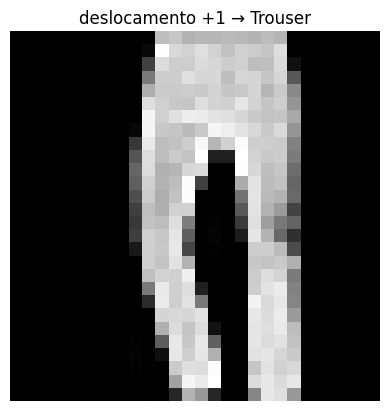

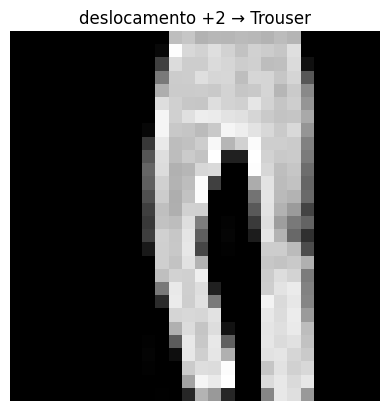

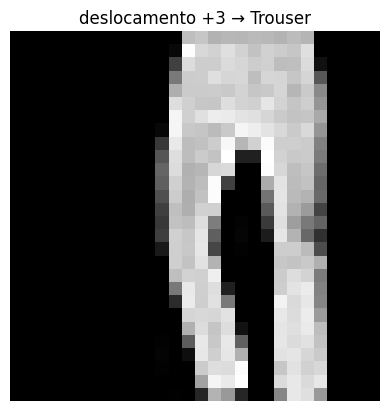

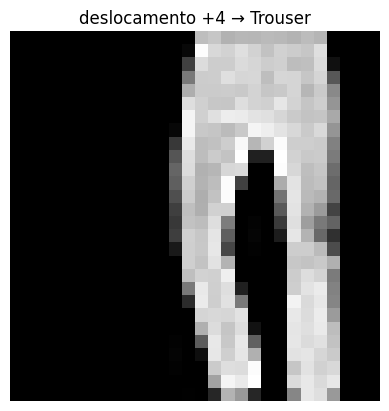

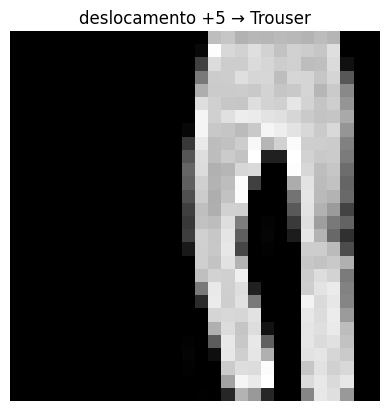

In [18]:
# testa a robustez do modelo
preds = []
ix = 24300 # índice da imagem de teste

for px in range(-5, 6):
    img   = tr_images[ix] / 255.
    img2  = np.roll(img.view(28, 28).numpy(), px, axis=1) # desloca a imagem
    img3  = torch.Tensor(img2).view(-1, 1, 28, 28).to(device)
    out   = model(img3).cpu().detach().numpy()
    pred  = np.exp(out) / np.sum(np.exp(out)) # softmax manual
    preds.append(pred)

    # exibe a imagem
    plt.imshow(img2, cmap='gray')
    plt.title(f'deslocamento {px:+d} → {fmnist.classes[pred[0].argmax()]}')
    plt.axis('off'); plt.show()